# Business Problem
The telecom company is losing recurring revenue due to customer churn. The goal is to identify high-risk customer segments early and understand the drivers of churn, so the company can take targeted retention actions.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Labelencoder- for categorical data encoding

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#import picklel

In [4]:
df = pd.read_csv('../Telecom customerr churn/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
# Drop customerID column as it is not useful for analysis
df.drop('customerID', axis=1, inplace=True)

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
# conver churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [15]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

This says that out of all customers, 26% of customers have churned that is left the companies product while the rest 73% are still using the same product.

<Axes: xlabel='Churn', ylabel='tenure'>

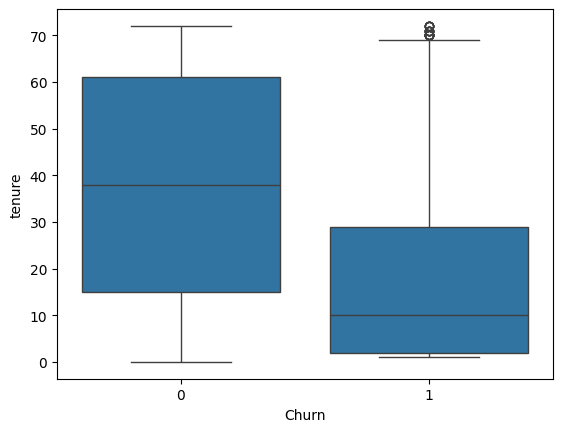

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [17]:
df.groupby('Churn')['tenure'].mean()

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

Another thing we can say is that the customers having less tenure, probably the churn would be in less then 17 months,  that is around 1.5years. So the customers who are churning uses the product for approx 1.5years and then switch.

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

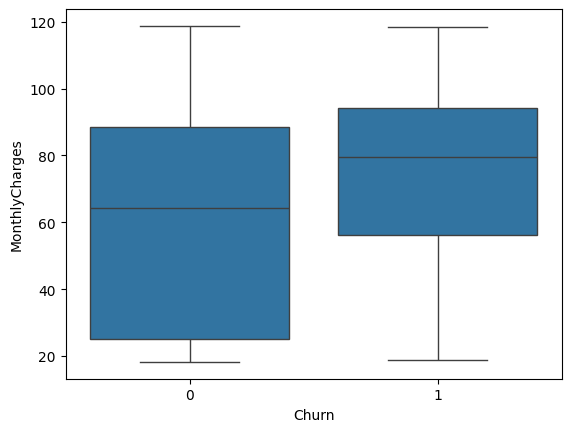

In [20]:
# Are churned customers paying more or less than non-churned customers?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
df.groupby('Churn')['MonthlyCharges'].mean()



Churn
0    2555.344141
1    1531.796094
Name: TotalCharges, dtype: float64

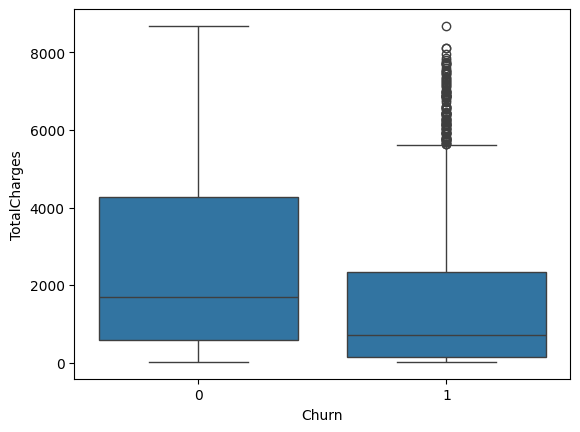

In [21]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)
df.groupby('Churn')['TotalCharges'].mean()

## Insight
the customers who churned, are paying more monthly charges whereas less totalcharges comparitvely to the one's who havent churned.

In [22]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Insight
Customers having month to month contracts have high probalility of churn, and there monthly charges are also more comparitively to the year ones.

In [38]:
pd.crosstab([df['Contract'], df['TechSupport']], df['Churn'], normalize='index')

Churn                                      0         1
Contract       TechSupport                            
Month-to-month No                   0.496269  0.503731
               No internet service  0.811069  0.188931
               Yes                  0.692996  0.307004
One year       No                   0.852783  0.147217
               No internet service  0.975275  0.024725
               Yes                  0.864130  0.135870
Two year       No                   0.940678  0.059322
               No internet service  0.992163  0.007837
               Yes                  0.964677  0.035323

In [ ]:
# Payment behavior
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Insights
Another factor of churn is the payment method, customers using electronic check have the highest probalility to churn.


In [30]:
# Service Usage
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,0,1
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Customers opting for fibre optics are likely to churn. Maybe there's a problem with the company's fibre optics servcie.

In [31]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100

Churn,0,1
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


this says that customers who opted for Online Security, only 14% churned where as the one's w/o online security churned a lot.

In [32]:
pd.crosstab(df['OnlineBackup'], df['Churn'], normalize='index') * 100

Churn,0,1
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


This says that the customers who took online backup srevice, got churned about 21% where who didnt took this service also churned about 39%. But its significant that the comapny needs to improve its online backup service.

In [33]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,0,1
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


The customers who had tech support havent churned much, where as the ones who doesnt had that churned a lot. It means the tech support is quite good.

In [ ]:
# Demographics
a = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
b = pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100
print(a)
print(b)

Churn                  0          1
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261
Churn               0          1
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


## Insights
Well it clearly indicates that senior citizen are more likely to churn, meanwhile if there are no dependents of customer, its more likely to churn.

In [40]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [47]:
pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100
(pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100).sort_values(by=1, ascending=False)


Churn,0,1
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
5,51.879699,48.120301
4,52.840909,47.159091
3,53.000000,47.000000
...,...,...
63,94.444444,5.555556
64,95.000000,5.000000
71,96.470588,3.529412


In [44]:
# Create the crosstab, sort by Churn '1' descending, and take the top 10
(pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100).sort_values(by=1, ascending=False).head(10)

Churn,0,1
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
5,51.879699,48.120301
4,52.840909,47.159091
3,53.000000,47.000000
7,61.068702,38.931298
10,61.206897,38.793103
9,61.344538,38.655462
15,62.626263,37.373737


So, we can atleast conclude that max churn is done in first 5 months.

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64